In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import splrep, splev

In [4]:
def r_s(M = 1.0):
    """
    Compute Schwarzschild Radius
    
    float M: Object mass in Msun units
    returns float: Schwarzschild Radius
    """
    return 2.*Mlen*M

def half_r_s(M= 1.0):
    """
    Compute Half-Schwarzschild Radius
    
    float M: Object mass in Msun units
    returns float: Half-Schwarzschild Radius
    """    
    return Mlen*M

def f(r, M):
    """
    Compute (-)gtt for Schwarzschild
    
    float r: radius
    returns float: (-)gtt 
    """
    return 1.0 - r_s(M)/r

def rhs_tau(tau, y):
    """
    Function for dormand prince step.
    ODEs computed starting from constant of motions.
    Mercury orbits are integrated using dr/dtau, dphi/dtau, dpr/dtau.

    float tau: proper time
    array (float) y: [radius, angle phi, radial velocity]

    returns:
    array (float) : dr/dtau, dphi/dtau, dpr/dtau
    """
    r, phi, pr = y

    dr_dtau = pr    
    dphi_dtau = L / r**2
    dpr_dtau = L*L/(r**3) - half_r_s(M)/r**2 - 3*half_r_s(M)*L*L/r**4

    return np.array([
        dr_dtau,
        dphi_dtau,
        dpr_dtau
    ])

def rhs_phi(phi, y):
    """
    Function for dormand prince step.
    ODEs computed using Binet formulation.
    Mercury orbits are integrated using u, du/dphi where u = 1/r

    float phi: 
    array (float) y: [u, du/dphi]

    returns:
    array (float) : u, du/dphi
    """
    u, up = y
    upp = half_r_s(M)/L**2 + 3*half_r_s(M) * u**2 - u
    return np.array([up, upp])

In [5]:
# Dormand Prince coefficients
c2, a21 = 1/5, 1/5
c3, a31, a32  = 3/10, 3/40, 9/40
c4, a41, a42, a43 = 4/5, 44/45, -56/15, 32/9
c5, c51, c52, c53, c54 = 8/9, 19372/6561, -25360/2187, 64448/6561, -212/729 
c6, c61, c62, c63, c64, c65 = 1.0, 9017/3168, -355/33, 46732/5247, 49/176, -5103/18656
c7, c71, c73, c74, c75, c76 = 1.0, 35/384, 500/1113, 125/192, -2187/6784, 11/84

# bi - bi*
e1 = 35/384-5179/57600
e3 = 500/1113-7571/16695
e4 = 125/192-393/640
e5 = -2187/6784+92097/339200
e6 = 11/84-187/2100
e7 = 0.0-1/40

def dormand_prince(var, y, h, variable):
    """
    Compute dormand-prince step.
    
    float var: proper time/angle (depending on which ODEs are solved)
    array (float) y: [radius, angle phi, radial velocity] or [u, du/dphi]
    float h: timestep
    string variable: determines which ODEs are solved

    returns array (float): evolved step yn+1 [radius, angle phi, radial velocity] or [u, du/dphi]
    """
    if variable == 'tau':
        rhs = rhs_tau
    elif variable == 'phi':
        rhs = rhs_phi

    k = np.zeros((7, len(y)))
    k[0] = rhs(var, y)
    k[1] = rhs(var + c2*h, y + h*a21*k[0])
    k[2] = rhs(var + c3*h, y + h*(a31*k[0] + a32*k[1]))
    k[3] = rhs(var + c4*h, y + h*(a41*k[0] + a42*k[1] + a43*k[2]))
    k[4] = rhs(var + c5*h, y + h*(c51*k[0] + c52*k[1] + c53*k[2] + c54*k[3]))
    k[5] = rhs(var + c6*h, y + h*(c61*k[0] + c62*k[1] + c63*k[2] + c64*k[3] + c65*k[4]))
    k[6] = rhs(var + c7*h, y + h*(c71*k[0] + 0.*k[1] + c73*k[2] + c74*k[3] + c75*k[4] + c76*k[5]))
    
    #numbers here are b_i - b*_i 
    err = h*(e1*k[0] + e3*k[2] + e4*k[3] + e5*k[4] + e6*k[5] + e7*k[6])
    y5 = y + h*(c71*k[0] + 0.*k[1] + c73*k[2] + c74*k[3] + c75*k[4] + c76*k[5])
    return y5, err, k

def adaptive_dormand_prince(var_0, var_f, y0, h_init, rtol=1e-10, atol=1e-15, variable='phi'):
    """
    Compute adaptive dormand-prince step.
    
    float var_0, var_f: integration range (can be 0, N*T or 0, N*2pi to do N orbits)
    array (float) y0: initial conditions array [radius, angle phi, radial velocity] or [u, du/dphi]
    float h_init: initial timestep, will be improved by adaptive step
    float rtol: relative tolerance
    float atol: absolute tolerance
    string variable: determines which ODEs are solved

    returns:
    array (vars): array of all times/angles evaluated (tau or phi)
    array (ys): all evolved steps [radius, angle phi, radial velocity] or [u, du/dphi]
    """
    y = y0
    var = var_0
    h = h_init
    vars = [var]
    ys = [y]
    safety = 0.9
    exp_err = 1/5

    while var < var_f:
        if var + h > var_f:     #ensure final step lands on var_f
            h = var_f - var

        #dormand prince step
        y5, err, _ = dormand_prince(var, y, h, variable)
        scale = atol + np.maximum(np.abs(y), np.abs(y5))*rtol       
        err_norm = np.linalg.norm(err/scale)/np.sqrt(len(y))        #error rescaling

        """ Timestep evaluation"""
        if err_norm <= 1.0:         #accepted timestep
            var += h
            y = y5
            vars.append(var)
            ys.append(y)

            # increase step size if too small
            if err_norm > 0:
                h = h * safety * err_norm**(-exp_err)
            
        else:                        #rejected timestep
            h = h * max(safety * err_norm**(-exp_err), 0.1)
    
    return np.array(vars), np.array(ys)

In [32]:
def find_perihelia_idx(r):
    """
    Find the indeces of perihelia in a set of radii.
    
    float r: radius
    """
    return np.where((r[1:-1] < r[:-2]) & (r[1:-1] < r[2:]))[0] + 1

def compute_mean_perihelia(phi, idx): 
    """ 
    Compute the mean precession from a set of perihelia. 
    
    float t: time 
    float r: radius float phi: angles 
    array (int) idx: indeces of perihelia 
    """ 
    phi = phi % (2*np.pi) #write phi in interval between [0, 2pi] 
    dphi = np.diff(phi[idx]) 
    return np.mean(dphi)

def compute_mean_perihelia_interp(idx_peri, phi, r, window=20, oversample=1000):
    """
    Find perihelia in (phi, r) and refine each one with a local spline,
    then return the per-orbit precession angles.
    Parameters
    ----------
    phi        : 1-D array of azimuthal angles [rad]
    r          : 1-D array of radii
    window     : number of points on each side of a crude perihelion to
                use for the local spline fit
    oversample : factor by which to subdivide the local phi grid
    Returns
    -------
    phi_peri   : 1-D array of refined perihelion angles [rad]
    dphi       : 1-D array of per-orbit angular advances  (phi_peri[i+1] - phi_peri[i] - 2π)
    dphi_mean  : float, mean precession per orbit [rad]
    """
    phi_peri = []
    for idx in idx_peri:
        lo = max(0,        idx - window)
        hi = min(len(r)-1, idx + window)

        phi_loc = phi[lo:hi+1]
        r_loc   = r[lo:hi+1]
        
        tck = splrep(phi_loc, r_loc, s=0)   # quartic spline → smooth minimum
        phi_fine = np.linspace(phi_loc[0], phi_loc[-1], phi_loc.size*oversample)
        r_fine   = splev(phi_fine, tck, der=0)
        phi_peri.append(phi_fine[np.argmin(r_fine)])
        
    phi_peri = np.array(phi_peri)
    # ---- 3.  Precession = angular advance beyond 2π per orbit ----
    dphi      = np.diff(phi_peri) - 2 * np.pi
    dphi_mean = float(np.mean(dphi))
    return dphi_mean

In [10]:
year_conversion = 3.156e7   # s in one year
rad_to_arcsec = 180/np.pi * 3600                
c = 299792458.0          # m/s renormalized to R0
G = 6.67430e-11       # m^3/(kg s^2) renormalized to R0
Msun = 1.98847e30           # kg
M = 1.                      # Msun
Mlen = G*Msun/(c*c)         # Schwarzschild mass parameter in km (GM/c^2) renormalized to R0

In [11]:
a = 5.7909227e10         #semi major axis renormalized to R0
e = 0.20563                 #eccentricity
M_mercury = 3.3e23          #Mercury Mass (Msun)

rp = a*(1.0-e)              #perihelion distance renormalized to R0
ra = a*(1.0+e)              #aphelion distance renormalized to R0

period = 0.240846           #orbit period (yr)
dphi_analytical = 6*np.pi*half_r_s(M)/(a*(1-e*e))
N_orbits_century = 100/period
rad_to_arcsec = 180/np.pi * 3600

### $\mathbf{(b)}$ Angular Momentum and Energy Derivation
Derive E and L from the condition $\frac{dr}{d\tau}$ = 0 at turning points $(r_p,\,r_a)$, solving $\rm V_{eff}(r_p) = V_{eff}(r_a) =  E^2$

In [12]:
gtt_rp = f(rp, M)
gtt_ra = f(ra, M)

L_squared = (gtt_ra-gtt_rp)/(gtt_rp/rp**2-gtt_ra/ra**2)
E_squared = gtt_ra*(1+L_squared/ra**2)
E_squared = gtt_rp*(1+L_squared/rp**2)

L = np.sqrt(L_squared)
E = np.sqrt(E_squared)
print('-------------  Check L, E -------------')
print('L squared =', L_squared)
E_squared = gtt_ra*(1+L_squared/ra**2)
print('E squared from ra =', E_squared)
E_squared = gtt_rp*(1+L_squared/rp**2)
print('E squared from rp =', E_squared)

print('Energy:', E)
print('Angular Momentum:', L)

-------------  Check L, E -------------
L squared = 81897009523033.3
E squared from ra = 0.99999997450027
E squared from rp = 0.9999999745002699
Energy: 0.9999999872501348
Angular Momentum: 9049696.653647197


### $\mathbf{(c)}$ Angular advance $\rm \Delta\phi = \phi_{return} - 2\pi$

Firstly, I integrate Mercury orbit for one period, which is given by:

\begin{equation*}
    T [s] = 2\pi\sqrt{\frac{a^3}{GM}} = 2\pi\sqrt{\frac{a^3 c^2}{c^2GM}} = 2\pi\sqrt{\frac{a^3}{c^2r_s/2}}
\end{equation*}

Since the integration is done in geometric units, the actual final time will be given by:

\begin{equation*}
    \rm T [geo] = c T [s] = 2\pi\sqrt{\frac{a^3}{GM}} = 2\pi\sqrt{\frac{a^3}{r_s/2}}
\end{equation*}

In [27]:
tf = 2*np.pi*np.sqrt(a**3/(half_r_s(M)))  #approximately the time needed to do one orbit
print('Final time:', tf)
h_convergence = tf/1000
time_results = []
y_results = []

tau_0 = 0
r_0 = rp
phi_0 = 0
pr_0 = 0

y0 = np.array([r_0, phi_0, pr_0])
y = y0
tau = tau_0
tau_list = [tau]
y_list = [y]

tau, y = adaptive_dormand_prince(0., tf, y0, h_convergence, rtol=1e-20, atol= 1e-25, variable='tau')

r = y[:, 0]
phi = y[:, 1]
pr = y[:, 2]

Final time: 2278556697154802.5


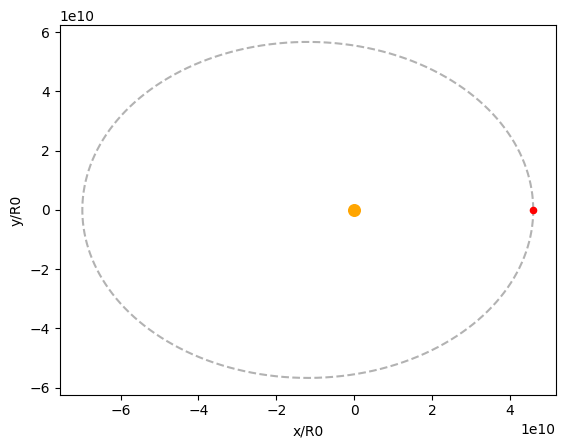

In [28]:
x = r*np.cos(phi)
y = r*np.sin(phi)

plt.scatter(0., 0., color = 'orange', s = 70)
plt.scatter(x[-1], y[-1], color = 'red', s = 20)
plt.plot(x, y, zorder = -1, color = 'grey', linestyle = '--', alpha = 0.6)
plt.xlabel('x/R0')
plt.ylabel('y/R0')
plt.show()

Then, I integrate for 10 orbits, detecting the return to perihelion by checking when $\rm\frac{dr}{d\tau}$ changes sign (from negative to positive).
Once the return is detected, I measure the angular advance $\rm \Delta\phi = \phi_{return}- 2\pi$. Also here the timestep used is constant throughout the full integration.

In [35]:
tf = 10*2*np.pi*np.sqrt(a**3/(half_r_s(M)))  #approximately the time needed to do one orbit
print('Final time:', tf)
h_convergence = tf/1000
time_results = []
y_results = []

tau_0 = 0
r_0 = rp
phi_0 = 0
pr_0 = 0

y0 = np.array([r_0, phi_0, pr_0])
y = y0
tau = tau_0
tau_list = [tau]
y_list = [y]

values = [[1e-10, 1e-15],  [1e-15, 1e-20], [1e-20, 1e-25], [1e-21, 1e-26]]

for val in values:
    print(f'------------------ rtol = {val[0]}, atol = {val[1]} -------------------')
    tau, y = adaptive_dormand_prince(0., tf, y0, h_convergence, rtol=val[0], atol=val[1], variable='tau')
    
    r = y[:, 0]
    phi = y[:, 1]
    pr = y[:, 2]
    idx_peri = find_perihelia_idx(r)
    dphi = compute_mean_perihelia(phi, idx_peri)
    print('------------- No Interpolation ----------------')
    print("Precession per orbit (radians):", dphi)

    print("Precession after a century:", dphi*N_orbits_century*rad_to_arcsec)

    dphi = compute_mean_perihelia_interp(idx_peri, phi, r)
    print('------------- With Interpolation ----------------')
    print("Precession per orbit (radians):", dphi)

    print("Precession after a century:", dphi*N_orbits_century*rad_to_arcsec)
    print('\n')

Final time: 2.2785566971548028e+16
------------------ rtol = 1e-10, atol = 1e-15 -------------------
------------- No Interpolation ----------------
Precession per orbit (radians): -0.7834353082116889
Precession after a century: -67094795.86765744
------------- With Interpolation ----------------
Precession per orbit (radians): 1.9612157688975174e-06
Precession after a century: 167.96201331157525


------------------ rtol = 1e-15, atol = 1e-20 -------------------
------------- No Interpolation ----------------
Precession per orbit (radians): 9.404825493974922e-05
Precession after a century: 8054.460145912697
------------- With Interpolation ----------------
Precession per orbit (radians): 5.877350454097652e-07
Precession after a century: 50.3346766257582


------------------ rtol = 1e-20, atol = 1e-25 -------------------


: 

The measured precession directly from the array computed is overestimated with respect to the analytical one, which is on the order of $\rm\Delta\phi = 5.02\cdot 10^{-7}\,rad$.
I believe this is due to the fact that I am trying to estimate the perihelion from a discrete array. 

Therefore, I tried to compute the perihelion precession both from the discrete array and an interpolated array with an higher dimension. As it can be seen in the code below, the obtained value gets closer to the theoretical expectation once a larger number of points is considered. 

I think that applying this method allows for lower values of rtol/atol and reduce the computational cost that would be required to get such a precision directly in the discretization of the orbit.

### $\mathbf{\rm{(d)}}$ Numerical Result Comparison

Now, I (try to) verify that the total procession over one century is $\rm \Delta\phi = 43\,arcsec/century$.
Using the ODEs given by $d/d\tau$ makes the computational times unmanageable, therefore I decided to switch to the Binet equations.

In [ ]:
tf = 451*2*np.pi*np.sqrt(a**3/half_r_s(M))   #final time for 10 orbits
print('Final time:', tf)
h_ini = tf/100
time_results = []
y_results = []

tau_0 = 0
r_0 = rp
phi_0 = 0
pr_0 = 0

y0 = np.array([r_0, phi_0, pr_0])

tau, y = adaptive_dormand_prince(tau_0, tf, y0, h_ini, rtol=1e-15, atol=1e-20, variable='tau')

r = y[:, 0]
phi = y[:, 1]
pr = y[:, 2]

idx_peri = find_perihelia_idx(r)
dphi = compute_mean_perihelia(phi, idx_peri)
print('------------- No Interpolation ----------------')
print("Precession per orbit (radians):", dphi)

print("Precession after a century:", dphi*N_orbits_century*rad_to_arcsec)

dphi = compute_mean_perihelia_interp(idx_peri, phi, r)
print('------------- With Interpolation ----------------')
print("Precession per orbit (radians):", dphi)

print("Precession after a century:", dphi*N_orbits_century*rad_to_arcsec)


Final time: 1.027629070416816e+18


: 

In [ ]:
idx_peri = find_perihelia_idx(r)
dphi = compute_mean_perihelia(phi, idx_peri)
print('------------- No Interpolation ----------------')
print("Precession per orbit (radians):", dphi)

print("Precession after a century:", dphi * N_orbits_century * rad_to_arcsec)

print('\n------------- Analytical Solution ----------------')
print('Precession per orbit (radians):', dphi_analytical)
print('Precession after a century:', dphi_analytical*N_orbits_century*rad_to_arcsec)

In [15]:
tf = 10*2*np.pi*np.sqrt(a**3/half_r_s(M)) 
h_convergence = [tf/1000, tf/2000, tf/4000]
time_results = []
y_results = []

for h in h_convergence:
    print(f"Running with step size h = {h}")
    t_values = [tau_0]
    y_values = [y0]
    tau = tau_0
    y = y0

    #Time integration with constant step size
    while tau < tf:
        if tau + h > tf:
            h = tf-tau
        y,_,_ = dormand_prince(tau, y, h, 'tau')
        tau = tau + h
        tau_list.append(tau)
        y_list.append(y)
    print('Check time:', tau)
    y_results.append(y[0])

N = np.log2(np.abs((y_results[0] - y_results[1])/(y_results[2] - y_results[1])))
print('-----------------------------------------')
print('Convergence order N:', N)

Running with step size h = 2278.5566971548033
Check time: 2278556.697154803
Running with step size h = 1139.2783485774016
Check time: 2278556.697154803
Running with step size h = 569.6391742887008
Check time: 2278556.697154803
-----------------------------------------
Convergence order N: 4.963727886875467


In [16]:
tf = tf + 0.3*tf
time_results = []
y_results = []

for h in h_convergence:
    print(f"Running with step size h = {h}")
    t_values = [tau_0]
    y_values = [y0]
    tau = tau_0
    y = y0

    #Time integration with constant step size
    while tau < tf:
        if tau + h > tf:
            h = tf-tau
        y,_,_ = dormand_prince(tau, y, h, 'tau')
        tau = tau + h
        tau_list.append(tau)
        y_list.append(y)
    print('Check time:', tau)
    y_results.append(y[0])

N = np.log2(np.abs((y_results[0] - y_results[1])/(y_results[2] - y_results[1])))
print('-----------------------------------------')
print('Convergence order N:', N)

Running with step size h = 2278.5566971548033
Check time: 2962123.706301244
Running with step size h = 1139.2783485774016
Check time: 2962123.706301244
Running with step size h = 569.6391742887008
Check time: 2962123.706301244
-----------------------------------------
Convergence order N: 4.963742898522333


### Bonus: Integration with Binet Equation

In [ ]:
phif = 10*2*np.pi                       #10 orbits in radians
print('Final angle:', phif)
h_convergence = phif/100

phi_0 = 0.
u_0 = 1/rp
du_dphi_0 = 0.

y0 = np.array([u_0, du_dphi_0])
phi, y = adaptive_dormand_prince(phi_0, phif, y0, h_convergence, rtol=1e-20, atol=1e-25, variable='phi')

r = 1/y[:, 0]
du_dphi = y[:, 1]

: 

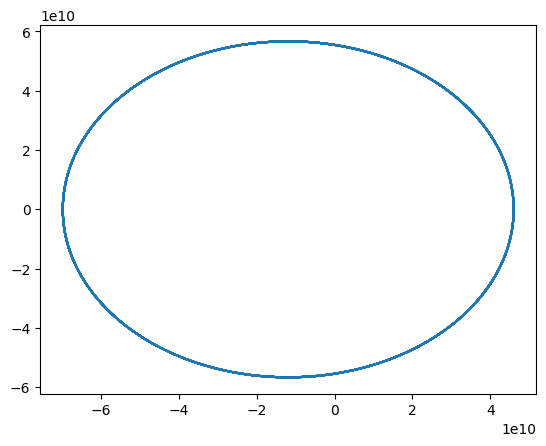

In [ ]:
x = r*np.cos(phi)
y = r*np.sin(phi)
plt.plot(x, y)

In [ ]:
tck  = splrep(phi, r, s=0)
xnew = np.linspace(phi[0], phi[-1], phi.size*500)

ynew = splev(xnew, tck, der=0)
dy   = splev(xnew, tck, der=1)

idx = np.where(np.diff(np.sign(dy)))[0][::2]
dphi = compute_mean_perihelia(xnew, idx)
print("Precession per orbit (radians):", dphi)

N_orbits_century = 100/period
rad_to_arcsec = 180/np.pi * 3600
print("Precession after a century:", dphi * N_orbits_century * rad_to_arcsec)

Precession per orbit (radians): 5.061771319129585e-07
Precession after a century: 43.34991157865911
